In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')

# Always run these first on every table
print(orders.shape)           # how many rows and columns
print(orders.dtypes)          # what type is each column
print(orders.isnull().sum())  # how many nulls in each column

(99441, 8)
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [4]:
print(orders.duplicated().sum())  # any duplicate rows

0


In [7]:
orders.head(5)               # look at first 10 rows

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.describe()             # basic statistics

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [9]:
# Set path to raw data
RAW_PATH = '../data/raw/'

# Load all 8 tables
orders = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')
customers = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')
products = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')
sellers = pd.read_csv(RAW_PATH + 'olist_sellers_dataset.csv')
payments = pd.read_csv(RAW_PATH + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')
geolocation = pd.read_csv(RAW_PATH + 'olist_geolocation_dataset.csv')

print("All tables loaded!")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Customers: {customers.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Geolocation: {geolocation.shape}")

All tables loaded!
Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Payments: (103886, 5)
Reviews: (99224, 7)
Geolocation: (1000163, 5)


In [ ]:
print("=== ORDERS TABLE ===")
print(f"Shape: {orders.shape}")
print(f"\nColumn Types:")
print(orders.dtypes)
print(f"\nNull Values:")
print(orders.isnull().sum())
print(f"\nDuplicate Rows: {orders.duplicated().sum()}")

=== ORDERS TABLE ===
Shape: (99441, 8)

Column Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Null Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows: 0

Order Status Breakdown:


In [13]:
print(f"\nOrder Status Breakdown:")
print(orders['order_status'].value_counts())


Order Status Breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [14]:
tables = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation
}

print("=== QUICK SUMMARY OF ALL TABLES ===\n")
for name, df in tables.items():
    nulls = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    print(f"{name.upper()}")
    print(f"  Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
    print(f"  Total Nulls: {nulls:,} | Duplicate Rows: {dupes:,}")
    print()

=== QUICK SUMMARY OF ALL TABLES ===

ORDERS
  Rows: 99,441 | Columns: 8
  Total Nulls: 4,908 | Duplicate Rows: 0

ORDER_ITEMS
  Rows: 112,650 | Columns: 7
  Total Nulls: 0 | Duplicate Rows: 0

CUSTOMERS
  Rows: 99,441 | Columns: 5
  Total Nulls: 0 | Duplicate Rows: 0

PRODUCTS
  Rows: 32,951 | Columns: 9
  Total Nulls: 2,448 | Duplicate Rows: 0

SELLERS
  Rows: 3,095 | Columns: 4
  Total Nulls: 0 | Duplicate Rows: 0

PAYMENTS
  Rows: 103,886 | Columns: 5
  Total Nulls: 0 | Duplicate Rows: 0

REVIEWS
  Rows: 99,224 | Columns: 7
  Total Nulls: 145,903 | Duplicate Rows: 0

GEOLOCATION
  Rows: 1,000,163 | Columns: 5
  Total Nulls: 0 | Duplicate Rows: 261,831



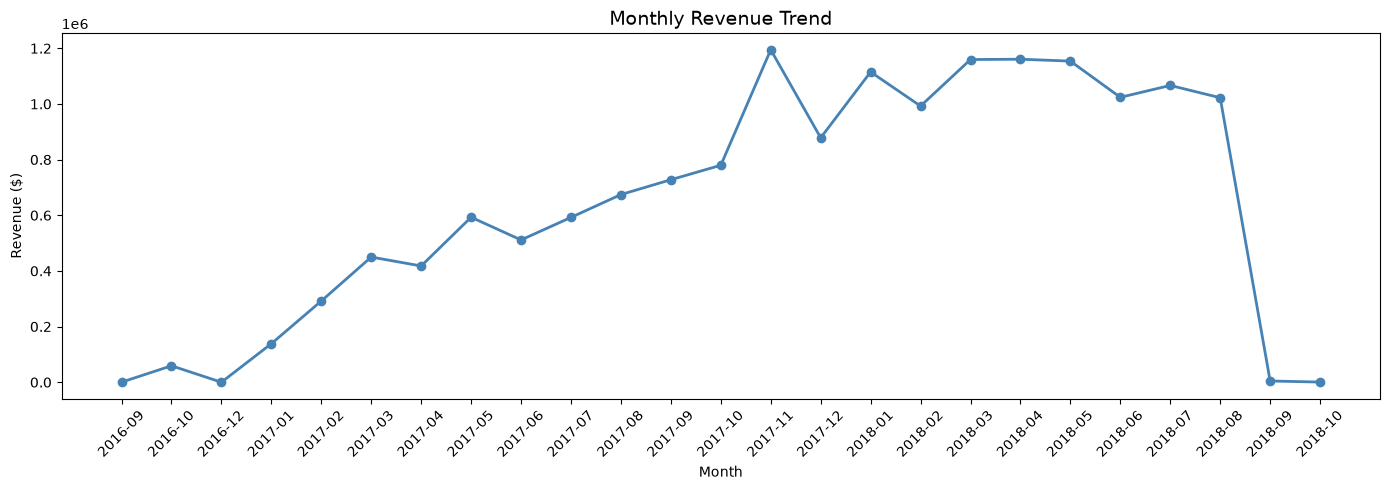

Chart saved!


In [15]:
# Merge orders with payments to get revenue
orders_payments = orders.merge(payments, on='order_id', how='left')

# Convert date column
orders_payments['order_purchase_timestamp'] = pd.to_datetime(
    orders_payments['order_purchase_timestamp']
)

# Extract month and year
orders_payments['year_month'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')

# Monthly revenue
monthly_revenue = orders_payments.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['year_month'], monthly_revenue['payment_value'], 
         marker='o', linewidth=2, color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('../analysis/monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

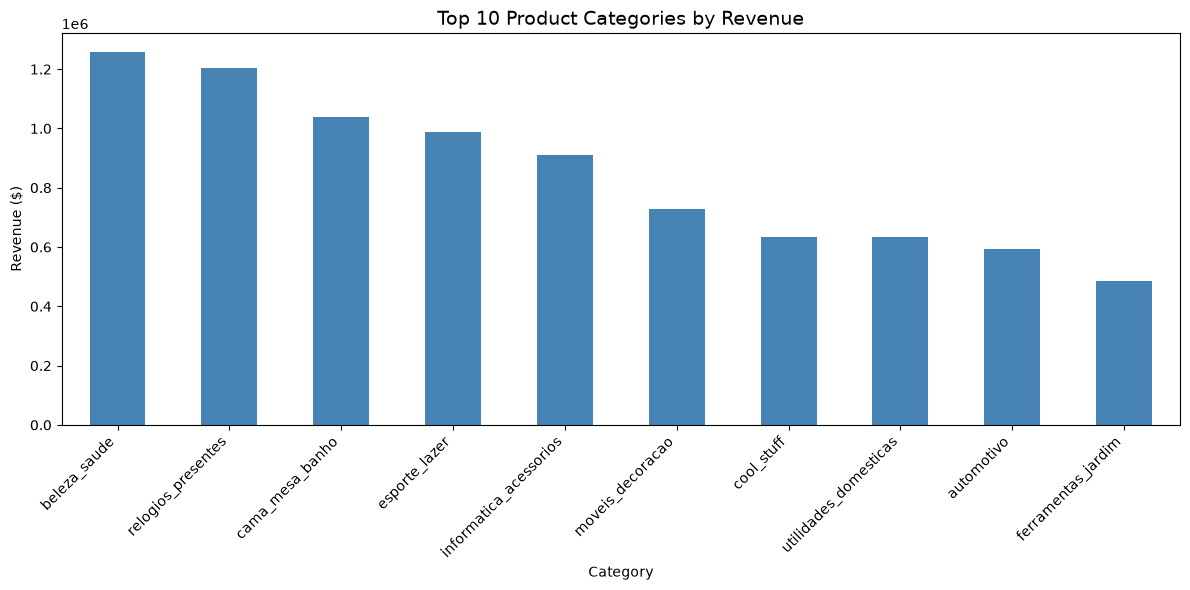

In [16]:
# Merge order items with products
items_products = order_items.merge(products, on='product_id', how='left')

# Revenue by category
category_revenue = items_products.groupby('product_category_name')['price'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
category_revenue.plot(kind='bar', color='steelblue')
plt.title('Top 10 Product Categories by Revenue', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../analysis/top_categories.png', dpi=150)
plt.show()

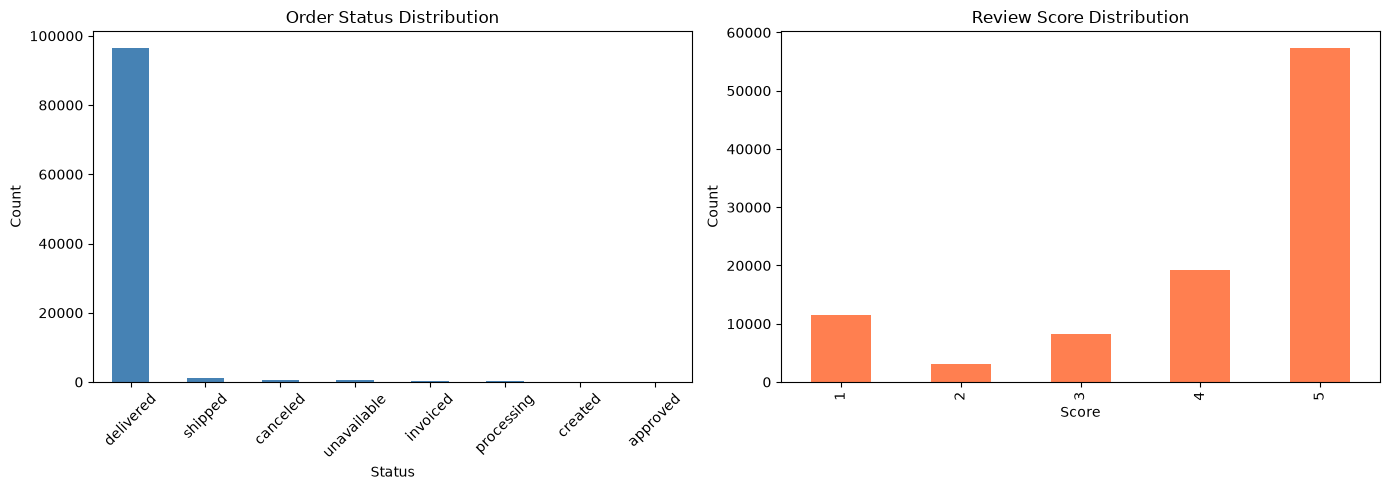

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order status
orders['order_status'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Order Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Review scores
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Review Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../analysis/status_reviews.png', dpi=150)
plt.show()

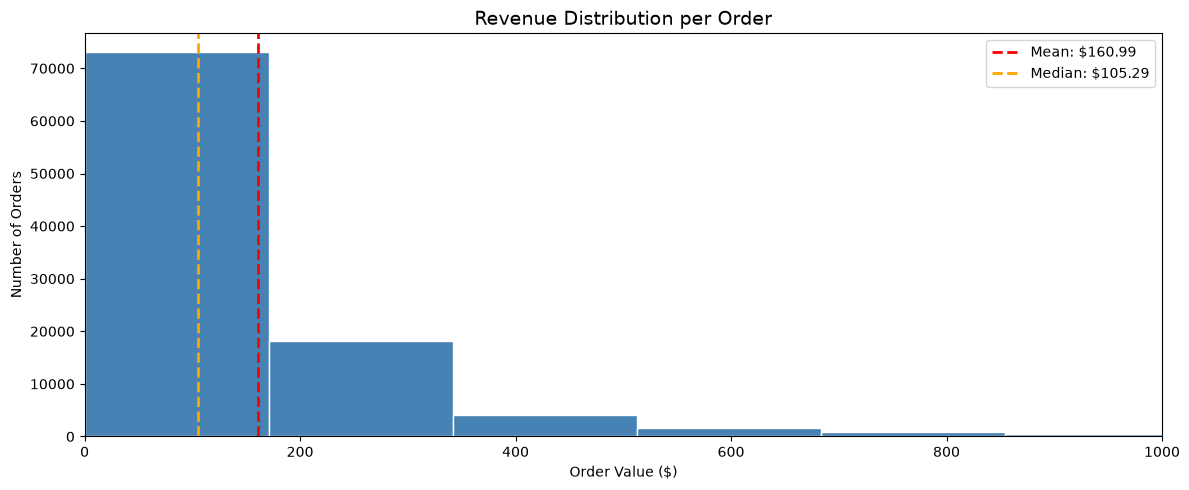

Mean order value: $160.99
Median order value: $105.29
Max order value: $13664.08
Skewness: 9.15 (positive = right skewed)


In [19]:
# Revenue distribution
order_totals = payments.groupby('order_id')['payment_value'].sum()

plt.figure(figsize=(12, 5))
plt.hist(order_totals, bins=80, color='steelblue', edgecolor='white')
plt.axvline(order_totals.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: ${order_totals.mean():.2f}')
plt.axvline(order_totals.median(), color='orange', linestyle='--', 
            linewidth=2, label=f'Median: ${order_totals.median():.2f}')
plt.title('Revenue Distribution per Order', fontsize=14)
plt.xlabel('Order Value ($)')
plt.ylabel('Number of Orders')
plt.xlim(0, 1000)
plt.legend()
plt.tight_layout()
plt.savefig('../analysis/revenue_distribution.png', dpi=150)
plt.show()

print(f"Mean order value: ${order_totals.mean():.2f}")
print(f"Median order value: ${order_totals.median():.2f}")
print(f"Max order value: ${order_totals.max():.2f}")
print(f"Skewness: {order_totals.skew():.2f} (positive = right skewed)")

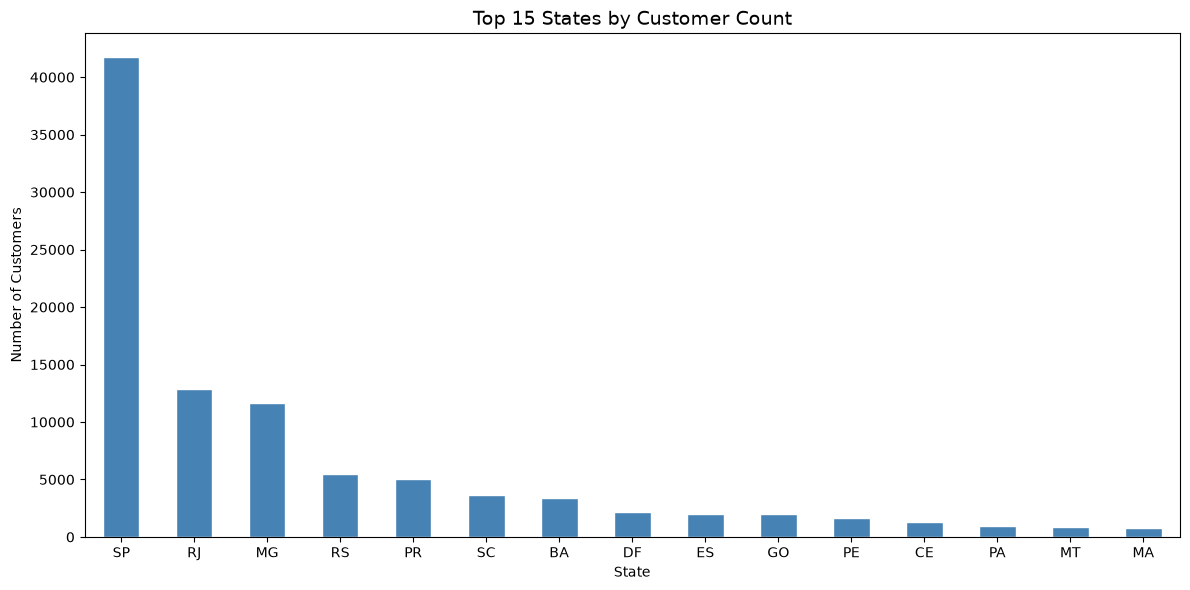


Top 5 states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

Total states represented: 27


In [20]:
# Customer geographic distribution
customer_state = customers['customer_state'].value_counts().head(15)

plt.figure(figsize=(12, 6))
customer_state.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 States by Customer Count', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../analysis/customer_by_state.png', dpi=150)
plt.show()

print("\nTop 5 states:")
print(customer_state.head())
print(f"\nTotal states represented: {customers['customer_state'].nunique()}")

In [18]:
print("=== KEY FINDINGS FROM EDA ===\n")

total_orders = len(orders)
delivered = len(orders[orders['order_status'] == 'delivered'])
total_revenue = payments['payment_value'].sum()
avg_order_value = payments.groupby('order_id')['payment_value'].sum().mean()
avg_review = reviews['review_score'].mean()

print(f"Total Orders: {total_orders:,}")
print(f"Delivered Orders: {delivered:,} ({delivered/total_orders*100:.1f}%)")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Average Review Score: {avg_review:.2f} / 5.0")
print(f"Total Customers: {customers['customer_unique_id'].nunique():,}")
print(f"Total Products: {products['product_id'].nunique():,}")
print(f"Total Sellers: {sellers['seller_id'].nunique():,}")

=== KEY FINDINGS FROM EDA ===

Total Orders: 99,441
Delivered Orders: 96,478 (97.0%)
Total Revenue: $16,008,872.12
Average Order Value: $160.99
Average Review Score: 4.09 / 5.0
Total Customers: 96,096
Total Products: 32,951
Total Sellers: 3,095
